# Dataset

## Import Libraries

In [1]:
!pip install datasets==3.6.0 --no-warn-conflicts --quiet

import os
import json
from pathlib import Path
import datasets
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
from google.colab import userdata

import torch
import torchvision
import huggingface_hub
from PIL import Image
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 12.2 MB/s eta 0:00:00


## Configuration

In [2]:
class Config:
    """
    Configuration class for the project.
    """
    # ========== Base Paths ==========
    project_name = "logo_recognition_similarity_search_project"
    base_dir = Path("/content/drive/MyDrive")/project_name
    output_dir = base_dir / "output"
    cache_dir = base_dir / "cache"

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)

    # ========== Dataset ==========
    dataset_path = "mlproject5606/Original-Logo-Recognition-Category-Dataset"
    dataset_cache_dir = cache_dir / dataset_path.split("/")[-1]
    category_indices_cache_dir = cache_dir / "Category-Indices-last"
    train_category_indices_path = category_indices_cache_dir / "category_train_indices.json"
    test_category_indices_path =  category_indices_cache_dir / "category_test_indices.json"
    val_category_indices_path =  category_indices_cache_dir / "category_val_indices.json"

    test_size = 0.2
    val_size = 0.1
    batch_size = 512  #512,2048,1024

    # ========== Runtime ==========
    device = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers = 4
    seed = 42





# Create Configuration Object
cfg = Config()

## Load Dataset

In [ ]:
ds = datasets.load_dataset(path = cfg.dataset_path,
                          split = "train",
                          token=userdata.get('HF_TOKEN')
                          )

ds

README.md:   0%|          | 0.00/470 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/76 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/76 [00:00<?, ?it/s]

train-00000-of-00076.parquet:   0%|          | 0.00/493M [00:00<?, ?B/s]

train-00001-of-00076.parquet:   0%|          | 0.00/497M [00:00<?, ?B/s]

...

train-00074-of-00076.parquet:   0%|          | 0.00/492M [00:00<?, ?B/s]

train-00075-of-00076.parquet:   0%|          | 0.00/491M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1777584 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/76 [00:00<?, ?it/s]

Dataset({
    features: ['id', 'path', 'prompt', 'image', 'path_category', 'category'],
    num_rows: 1777584
})

In [ ]:
ds.features

{'id': Value(dtype='string', id=None),
 'path': Value(dtype='string', id=None),
 'prompt': Value(dtype='string', id=None),
 'image': Image(mode=None, decode=True, id=None),
 'path_category': Value(dtype='string', id=None),
 'category': Value(dtype='int32', id=None)}

In [ ]:
ds = ds.select_columns(["id","path","prompt","image","category"])
ds

Dataset({
    features: ['id', 'path', 'prompt', 'image', 'category'],
    num_rows: 1777584
})

## Split Dataset

In [ ]:
# Get the unique categories from the dataset
unique_categories = sorted(list(set(ds["category"])))
num_unique_categories = len(unique_categories)
max_category_id = unique_categories[-1]

print(f"Number of unique categories: {num_unique_categories}")
print(f"Maximum unique category ID: {max_category_id}")
category_names = [str(i) for i in range(max_category_id + 1)]

# Create a ClassLabel feature using the generated names
category_feature = datasets.ClassLabel(names=category_names)
# Verify the number of classes in the created ClassLabel feature
print(f"Number of classes in ClassLabel feature: {category_feature.num_classes}")

Number of unique categories: 209310
Maximum unique category ID: 209310
Number of classes in ClassLabel feature: 209311


In [ ]:
# Update the features of the dataset
ds_features = ds.features.copy()
ds_features.update({"category": category_feature})

ds = ds.cast(features=ds_features,
             num_proc=cfg.num_workers
             )

Casting the dataset (num_proc=4):   0%|          | 0/1777584 [00:00<?, ? examples/s]

In [ ]:
ds

Dataset({
    features: ['id', 'path', 'prompt', 'image', 'category'],
    num_rows: 1777584
})

In [ ]:
split = ds.train_test_split(test_size=cfg.test_size,
                            stratify_by_column="category",
                            shuffle=True,
                            seed=cfg.seed
                            )

train_ds , test_ds = split["train"] , split["test"]
train_ds , test_ds

(Dataset({
     features: ['id', 'path', 'prompt', 'image', 'category'],
     num_rows: 1422067
 }),
 Dataset({
     features: ['id', 'path', 'prompt', 'image', 'category'],
     num_rows: 355517
 }))

In [ ]:
split = train_ds.train_test_split(test_size=cfg.val_size,
                                  shuffle=True,
                                  seed=cfg.seed
                                  )

train_ds , val_ds = split["train"] , split["test"]
train_ds , val_ds

(Dataset({
     features: ['id', 'path', 'prompt', 'image', 'category'],
     num_rows: 1279860
 }),
 Dataset({
     features: ['id', 'path', 'prompt', 'image', 'category'],
     num_rows: 142207
 }))

In [ ]:
split_ds = datasets.DatasetDict({"train": train_ds,
                                 "validation": val_ds,
                                 "test": test_ds
                                 })
split_ds

DatasetDict({
    train: Dataset({
        features: ['id', 'path', 'prompt', 'image', 'category'],
        num_rows: 1279860
    })
    validation: Dataset({
        features: ['id', 'path', 'prompt', 'image', 'category'],
        num_rows: 142207
    })
    test: Dataset({
        features: ['id', 'path', 'prompt', 'image', 'category'],
        num_rows: 355517
    })
})

In [11]:
for split in ["validation","test","train"]:
    dss = split_ds[split]
    ds_features = dss.features.copy()
    category_feature = datasets.Value("int32")
    ds_features.update({"category": category_feature})
    dss = dss.cast(features=ds_features,
                   num_proc=cfg.num_workers
                   )
    dss.push_to_hub("mlproject5606/Original-Logo-Recognition-Category-Split-Dataset",
                    split=split,
                    private=True,
                    token=userdata.get('HF_TOKEN'),
                    )



Uploading the dataset shards:   0%|          | 0/7 [00:00<?, ?it/s]

Map:   0%|          | 0/20316 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/204 [00:00<?, ?ba/s]

Map:   0%|          | 0/20316 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/204 [00:00<?, ?ba/s]

...

Map:   0%|          | 0/23270 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/233 [00:00<?, ?ba/s]

Map:   0%|          | 0/23270 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/233 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/547 [00:00<?, ?B/s]

## Category Indices

In [ ]:
from collections import defaultdict

def create_category_indices(ds, file_path):
    """
    Create a dictionary mapping categories to their corresponding indices in the dataset.
    """
    category_indices_cache_dir = os.path.dirname(file_path)
    os.makedirs(category_indices_cache_dir, exist_ok=True)
    category_to_indices = defaultdict(list)

    for idx, example in enumerate(tqdm(ds, desc="Building category to indices")):
        category_to_indices[example['category']].append(idx)

    with open(file_path, 'w') as f:
        json.dump(category_to_indices, f)

    print(f"[INFO] Saved category_to_indices to: {file_path}")
    return category_to_indices

In [ ]:
train_category_indices = create_category_indices(ds=train_ds,
                                                 file_path=cfg.train_category_indices_path,
                                                 )

print(f"[INFO] Number of categories in train_category_indices: {len(train_category_indices)}")

Building category to indices: 100%|██████████| 1279860/1279860 [16:38<00:00, 1281.21it/s]


[INFO] Saved category_to_indices to: /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices-last/category_train_indices.json
[INFO] Number of categories in train_category_indices: 207902


In [ ]:
test_category_indices = create_category_indices(ds=test_ds,
                                                file_path=cfg.test_category_indices_path,
                                                )

print(f"[INFO] Number of categories in test_category_indices: {len(test_category_indices)}")

Building category to indices: 100%|██████████| 355517/355517 [04:01<00:00, 1469.45it/s]


[INFO] Saved category_to_indices to: /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices-last/category_test_indices.json
[INFO] Number of categories in test_category_indices: 135881


In [ ]:
val_category_indices = create_category_indices(ds=val_ds,
                                               file_path=cfg.val_category_indices_path,
                                               )

print(f"[INFO] Number of categories in val_category_indices: {len(val_category_indices)}")

Building category to indices: 100%|██████████| 142207/142207 [01:23<00:00, 1702.28it/s]


[INFO] Saved category_to_indices to: /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices-last/category_val_indices.json
[INFO] Number of categories in val_category_indices: 63673


In [ ]:
category_indices = train_category_indices.copy()

for category, indices in test_category_indices.items():
    if category not in category_indices:
        category_indices[category] = indices
    else:
        category_indices[category].extend(indices)

for category, indices in val_category_indices.items():
    if category not in category_indices:
        category_indices[category] = indices
    else:
        category_indices[category].extend(indices)


with open(cfg.category_indices_cache_dir / "category_indices.json", 'w') as f:
    json.dump(category_indices, f)

print(f"[INFO] Saved category_indices to: {cfg.category_indices_cache_dir / 'category_indices.json'}")
print(f"[INFO] Number of categories in category_indices: {len(category_indices)}")

[INFO] Saved category_indices to: /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices-last/category_indices.json
[INFO] Number of categories in category_indices: 209310


In [ ]:
category_indices_split = {
    "all": category_indices,
    "train": train_category_indices,
    "test": test_category_indices,
    "validation": val_category_indices
}

with open(cfg.category_indices_cache_dir / "category_indices_split.json", 'w') as f:
    json.dump(category_indices_split, f)

In [ ]:
repo_id = "mlproject5606/Category_Indices_Split_Dataset"
folder_path=cfg.category_indices_cache_dir
repo_type = "dataset"

huggingface_hub.create_repo(repo_id=repo_id,
                            repo_type=repo_type,
                            private=True,
                            exist_ok=True
                            )

huggingface_hub.HfApi().upload_folder(
    folder_path=folder_path,
    repo_id=repo_id,
    repo_type=repo_type,
    token=userdata.get('HF_TOKEN')
    )


category_indices.json:   0%|          | 0.00/16.6M [00:00<?, ?B/s]

Upload 3 LFS files:   0%|          | 0/3 [00:00<?, ?it/s]

category_train_indices.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

category_indices_split.json:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/mlproject5606/Category_Indices_Split_Dataset/commit/e725e7cf3c0c46696c734042717644976378a7b9', commit_message='Upload folder using huggingface_hub', commit_description='', oid='e725e7cf3c0c46696c734042717644976378a7b9', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/mlproject5606/Category_Indices_Split_Dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='mlproject5606/Category_Indices_Split_Dataset'), pr_revision=None, pr_num=None)

## Triplet Dataset & DataLoader

In [3]:
import json
import random
import torch
import datasets


class TripletDataset(torch.utils.data.Dataset):
    """
    Custom dataset class for triplet network.
    """

    def __init__(self,
                 ds:datasets.Dataset,
                 category_indices_path:str,
                 seed:int=None,
                 ):
        """
        Initialize the TripletDataset.
        """
        print(f"[INFO] Initializing Triplet Dataset")

        self.ds = ds
        self.seed = seed
        self.rng = random.Random() if seed is None else random.Random(seed)
        self.category_indices_path = category_indices_path

        print(f"[INFO] Loading category indices from: {self.category_indices_path}")
        self.category_indices = self._load_category_indices(self.category_indices_path)
        self.categories = sorted(list(self.category_indices.keys()))

        print(f"[INFO] Triplet Dataset Initialized")



    def _load_category_indices(self, category_indices_path):
        """
        Load category indices from a JSON file.
        """
        with open(category_indices_path, "r") as f:
            category_indices = json.load(f)
        category_indices = {int(k): v for k, v in category_indices.items()}
        return category_indices

    def __len__(self):
        """
        Return the number of samples in the dataset.
        """
        return len(self.ds)


    def _get_positive(self, category, anchor_idx=None):
        """
        Get a positive item for the given anchor index and category.
        """
        positive_indices = self.category_indices[category]
        if len(positive_indices)<2:
            positive_idx = positive_indices[0]

        elif anchor_idx is None:
            positive_idx = self.rng.choice(positive_indices)

        else:
            positive_idx = anchor_idx
            while positive_idx==anchor_idx:
                positive_idx = self.rng.choice(positive_indices)

        return self.ds[positive_idx]


    def _get_negative(self, category):
        """
        Get a negative item for the given anchor category.
        """
        negative_category = category
        while negative_category==category:
            negative_category = self.rng.choice(self.categories)

        negative_indices = self.category_indices[negative_category]
        negative_idx = self.rng.choice(negative_indices)
        return self.ds[negative_idx]


    def __getitem__(self, idx):
        """
        Get a triplet sample from the dataset.
        """
        anchor_idx = idx
        anchor = self.ds[anchor_idx]
        category = int(anchor["category"])

        positive = self._get_positive(category=category,
                                      anchor_idx=anchor_idx
                                      )


        negative = self._get_negative(category=category)


        return anchor , positive , negative

    @staticmethod
    def display_sample(sample):
        """
        Display the anchor, positive, and negative images.
        """
        images = []
        for i in range(len(sample)):
            image = sample[i]["image"]
            if isinstance(image, Image.Image):
                image = np.array(image)
            elif isinstance(image, torch.Tensor):
                image = image.permute(1, 2, 0).numpy()
            images.append(image)

        fig, axes = plt.subplots(1, 3, figsize=(10, 5))
        axes[0].imshow(images[0])
        axes[0].set_title(f"Anchor cat({sample[0]['category']})")

        axes[1].imshow(images[1])
        axes[1].set_title(f"Positive cat({sample[1]['category']})")

        axes[2].imshow(images[2])
        axes[2].set_title(f"Negative cat({sample[2]['category']})")

        for ax in axes:
            ax.axis("off")
        plt.show()

    @staticmethod
    def collate_fn(batch):
        """
        Collate function to process triplet batch for HuggingFace Trainer.

        Args:
            batch: List of (anchor_dict, positive_dict, negative_dict)

        Returns:
            Dict with keys 'anchor', 'positive', 'negative', each containing image batch tensor
        """
        anchors, positives, negatives = zip(*batch)

        anchor_images = torch.stack([item["image"].float()/255.0 for item in anchors])
        positive_images = torch.stack([item["image"].float()/255.0 for item in positives])
        negative_images = torch.stack([item["image"].float()/255.0 for item in negatives])

        return {
            "anchor": anchor_images,
            "positive": positive_images,
            "negative": negative_images
        }

In [4]:
cfg = Config()
cfg.dataset_path = "mlproject5606/Original-Logo-Recognition-Category-Split-Dataset"
cfg.dataset_cache_dir = cfg.cache_dir / cfg.dataset_path.split("/")[-1]

In [5]:
ds = datasets.load_dataset(path = cfg.dataset_path,
                           cache_dir = cfg.dataset_cache_dir,
                           )

ds = ds.with_format('torch')
ds

README.md:   0%|          | 0.00/658 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

validation-00000-of-00007.parquet:   0%|          | 0.00/430M [00:00<?, ?B/s]

validation-00001-of-00007.parquet:   0%|          | 0.00/430M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/142207 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/355517 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1279860 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/55 [00:00<?, ?it/s]

DatasetDict({
    validation: Dataset({
        features: ['id', 'path', 'prompt', 'image', 'category'],
        num_rows: 142207
    })
    test: Dataset({
        features: ['id', 'path', 'prompt', 'image', 'category'],
        num_rows: 355517
    })
    train: Dataset({
        features: ['id', 'path', 'prompt', 'image', 'category'],
        num_rows: 1279860
    })
})

In [6]:
ds['train'].features

{'id': Value(dtype='string', id=None),
 'path': Value(dtype='string', id=None),
 'prompt': Value(dtype='string', id=None),
 'image': Image(mode=None, decode=True, id=None),
 'category': Value(dtype='int32', id=None)}

In [8]:
train_dataset = TripletDataset(ds=ds["train"],
                               category_indices_path=cfg.train_category_indices_path,
                               seed=None
                               )

print(f"[INFO] Number of samples in train_dataset: {len(train_dataset)}")

[INFO] Initializing Triplet Dataset
[INFO] Loading category indices from: /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices-last/category_train_indices.json
[INFO] Triplet Dataset Initialized
[INFO] Number of samples in train_dataset: 1279860


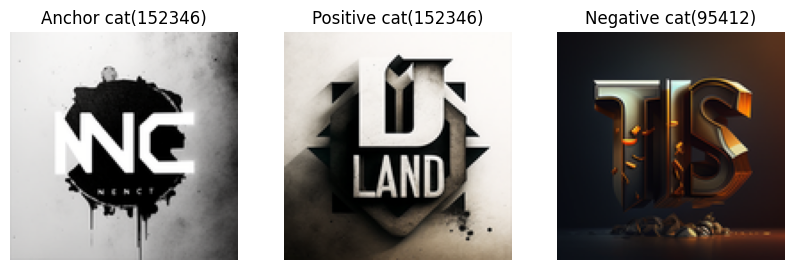

In [9]:
index = 0
sample = train_dataset[index]
TripletDataset.display_sample(sample)

In [10]:
train_loader  = torch.utils.data.DataLoader(train_dataset,
                                            batch_size=cfg.batch_size,
                                            )
print(f"[INFO] Number of batches in train loader: {len(train_loader)}")

[INFO] Number of batches in train loader: 2500


In [11]:
%%time
batch = next(iter(train_loader))

CPU times: user 18.1 s, sys: 463 ms, total: 18.6 s
Wall time: 5.24 s


In [12]:
anchors, positives, negatives = batch

In [13]:
anchors.keys()

dict_keys(['id', 'path', 'prompt', 'image', 'category'])

In [14]:
(anchors["image"].shape,
 positives["image"].shape,
 negatives["image"].shape
)

(torch.Size([512, 3, 128, 128]),
 torch.Size([512, 3, 128, 128]),
 torch.Size([512, 3, 128, 128]))

In [15]:
val_dataset = TripletDataset(ds=ds["validation"],
                             category_indices_path=cfg.val_category_indices_path,
                             seed=None
                             )

print(f"[INFO] Number of samples in val_dataset: {len(val_dataset)}")

[INFO] Initializing Triplet Dataset
[INFO] Loading category indices from: /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices-last/category_val_indices.json
[INFO] Triplet Dataset Initialized
[INFO] Number of samples in val_dataset: 142207


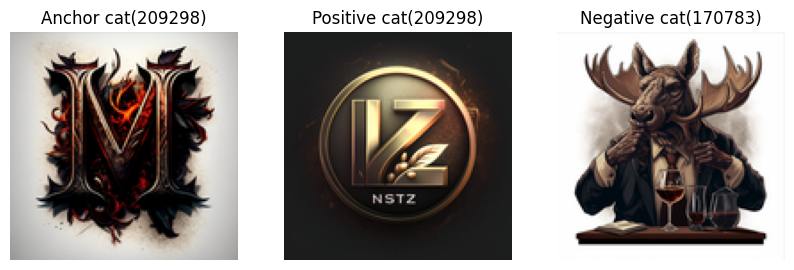

In [16]:
index = 0
sample = val_dataset[index]
val_dataset.display_sample(sample)

In [17]:
val_loader  = torch.utils.data.DataLoader(val_dataset,
                                          batch_size=cfg.batch_size,
                                          )

print(f"[INFO] Number of batches in val loader: {len(val_loader)}")

[INFO] Number of batches in val loader: 278


In [18]:
%%time
batch = next(iter(val_loader))

CPU times: user 14.6 s, sys: 668 ms, total: 15.3 s
Wall time: 4.19 s


In [19]:
anchors, positives, negatives = batch

In [20]:
anchors.keys()

dict_keys(['id', 'path', 'prompt', 'image', 'category'])

In [21]:
(anchors["image"].shape,
 positives["image"].shape,
 negatives["image"].shape
)

(torch.Size([512, 3, 128, 128]),
 torch.Size([512, 3, 128, 128]),
 torch.Size([512, 3, 128, 128]))

## Disconnect

In [ ]:
# Disconnect and delete the current runtime in Google Colab
from google.colab import runtime

runtime.unassign()